In [1]:
import numpy as np
from utils import *

# Evolution of the meter system during the Quantum Phase Estimation protocol

In this notebook, we visualize the evolution of the ancillary system during the Quantum Phase Estimation (QPE) protocol.


## 1. Objective of the protocol

Consider a unitary operator $U$ and its eigenstate $|\psi\rangle$. The eigenvalue is represented as a phase factor containing the parameter $\phi$:

$$U|\psi\rangle = e^{2\pi i \phi / N}|\psi\rangle$$

Since the phase factor is periodic, we restrict the range of $\phi$ to $[0, N)$.

**The objective** of Quantum Phase Estimation (QPE) is to estimate the value of $\phi$.

**Note**: Different literature (e.g., Nielsen & Chuang) may use different conventions for the range of $\phi$. In this notebook, we use the following values for $\phi$ and $N$:

In [8]:
phi = 13.3
N = 32

## 2. Resources

To perform the estimation, we assume access to the following resources:

* **An ancillary qudit** with $N$ levels, denoted by the basis states:
  $$|0\rangle, |1\rangle, \dots, |N-1\rangle$$
  *(Note: In many implementations, this qudit is composed of a register of $n$ qubits, where $N=2^n$. here we treat it as a general $N$-level system.)*

* **The eigenstate** $|\psi\rangle$ of the unitary $U$.

* **A controlled-unitary operator** $C_U$, which uses the ancillary qudit as the control and $|\psi\rangle$ as the target:
  $$C_U|k\rangle|\psi\rangle = |k\rangle U^k |\psi\rangle$$

As a controlled operation, for $k=0$, $U^0 = I$, giving $C_U|0\rangle|\psi\rangle = |0\rangle|\psi\rangle$. By substituting the eigenvalue equation, the action becomes:

$$C_U|k\rangle|\psi\rangle = |k\rangle e^{2\pi i \phi k / N}|\psi\rangle = e^{2\pi i \phi k / N} |k\rangle |\psi\rangle$$

This interaction encodes the phase information onto the amplitudes of the control qudit.

## 3. Initialization of the Ancilla Qudit

The qudit is initialized in an equal superposition of all basis states:

$$|\alpha_0\rangle = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1}|k\rangle$$

We represent this state in the notebook as a `numpy` array of complex coefficients.

In [9]:
qudit_state = np.ones(N) / np.sqrt(N)

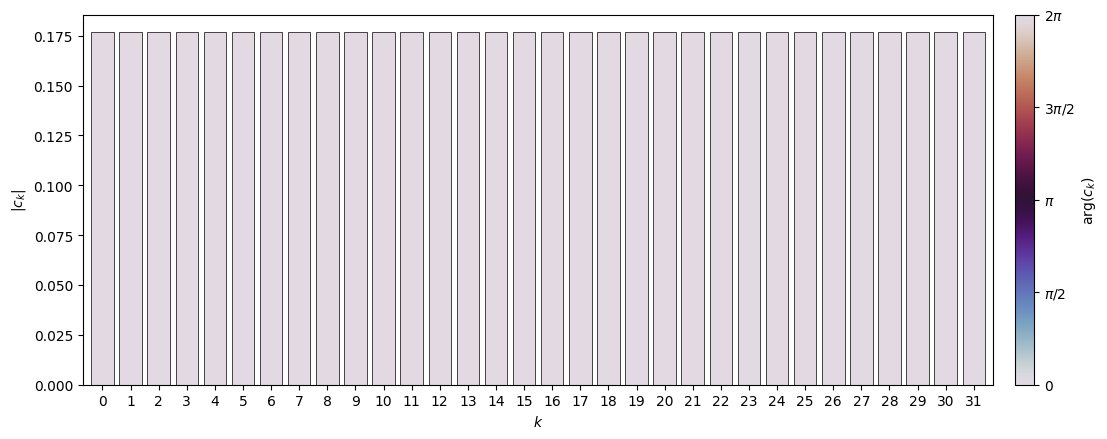

In [10]:
plot_qudit_state(qudit_state)

## 4. Phase Encoding

We apply the controlled-unitary $C_U$. The resulting state of the system is:

$$C_U | \alpha_0\rangle |\psi\rangle = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} e^{2\pi i \phi k/N} |k\rangle |\psi\rangle$$

At this stage, the phase $\phi$ is encoded as a linear phase gradient across the basis states of the qudit.

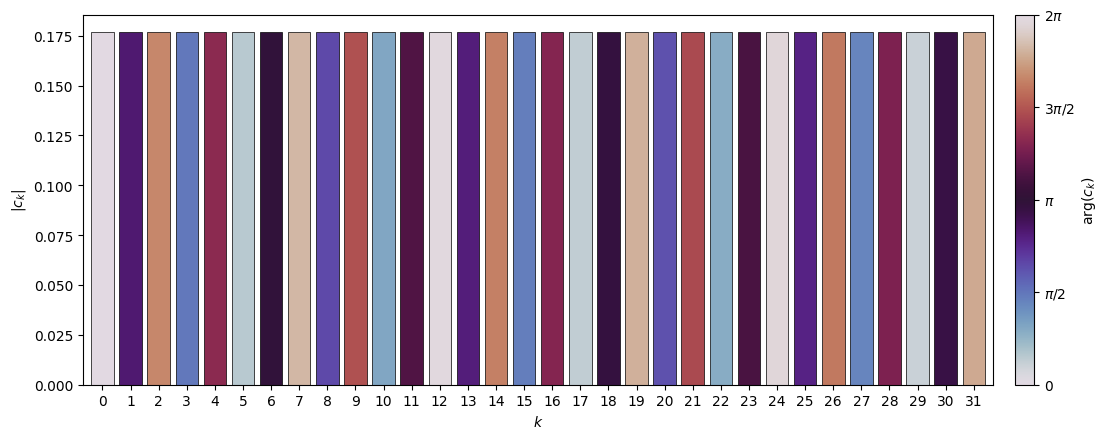

In [11]:
# State update
k_array = np.arange(N)
qudit_state_1 = qudit_state * np.exp(2 * np.pi * 1j * phi * k_array / N)
plot_qudit_state(qudit_state_1)

## 5. Inverse Quantum Fourier Transform (IQFT)

To extract the value of $\phi$, we apply the Inverse QFT ($\mathcal{F}^{\dagger}$) to the qudit. The IQFT maps the phase gradient back into the computational basis:

$$\mathcal{F}^{\dagger}|k\rangle = \frac{1}{\sqrt{N}}\sum_{q=0}^{N-1}e^{-2\pi i kq/N}|q
\rangle$$

If $\phi$ is an integer, the resulting state will be the basis state $|\phi\rangle$. If $\phi$ is not an integer, we expect a distribution peaked around $\phi$.

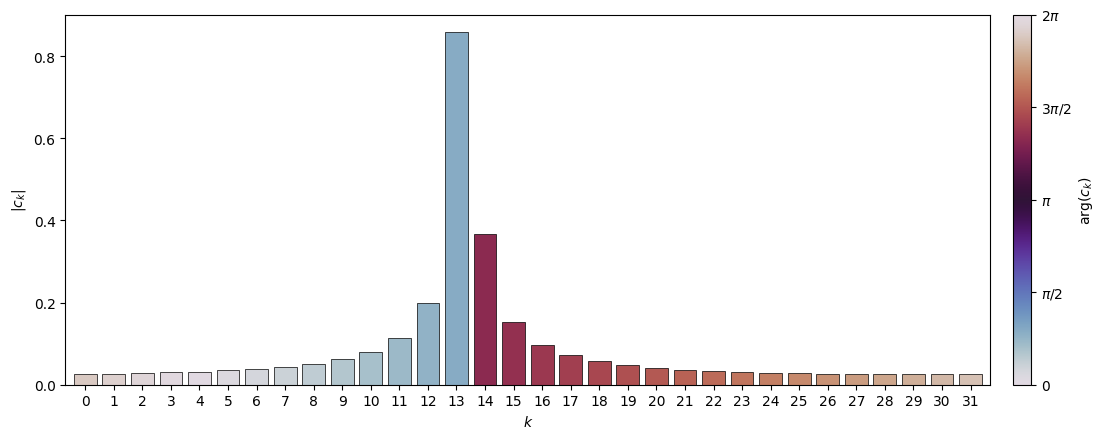

In [12]:
qudit_state_2 = np.fft.fft(qudit_state_1, norm="ortho")
plot_qudit_state(qudit_state_2)

The peak should be near phi = 13.3
The plot below shows the probability distribution


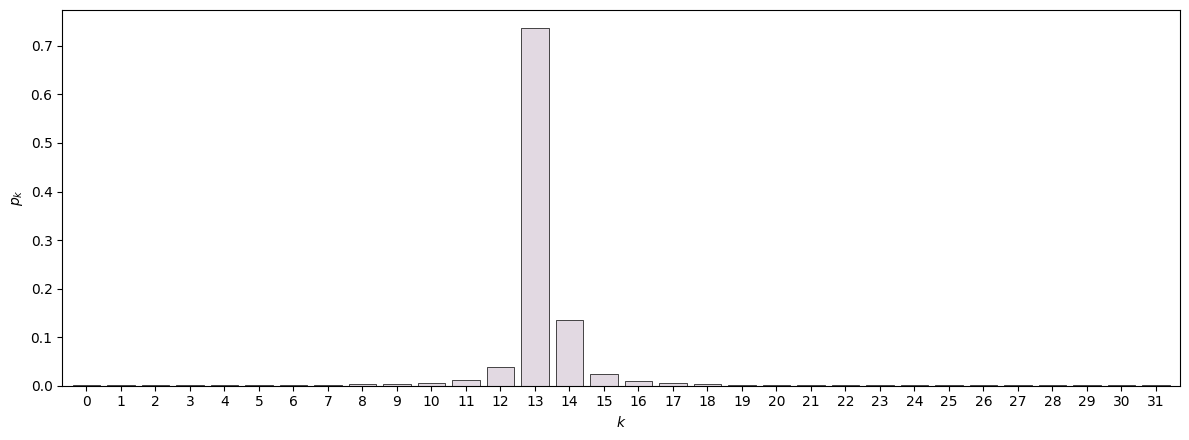

In [13]:
print(f"The peak should be near {phi = }")
print("The plot below shows the probability distribution")
plot_qudit_state(qudit_state_2, "probs")